# Data Mining Project Template (GitHub + Colab)
## Haley Benge
## April 12th, 2026
## Loan Approval Model

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.3 MB/s eta 0:00:00
Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Deliverable 1: Problem Framing & Data Acquisition





 - This model will determine if someone is approved for a loan.
 - The target variable in use is 'loan_status'. - Financial instituitions such as banks or lenders could use this model for risk assessment and loan underwriting.
 - Loan approval matters because money lending is risky and approving too many high risk applicants can cause an institution to lose mass amounts of money. Decision making traditionally can take a lot of time, and be inconsistent or biased. This model could speed up decision making and reduce manuel review times, apply consistent and uninfluenced criteria to all applicants, and can expand approval rates for clients that may not fit traditional criteria but are applicable for loans.
 - This dataset is from kaggle.com [https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset?utm_source=chatgpt.com]
 - I chose this dataset because I intend to go into financial analytics or loan underwriting. This gives me an opportunity to gain real world experience and apply classroom knowledge directly to data that I am encounter in the near future.

In [2]:
# Loading in the data from csv file
data_url = "https://raw.githubusercontent.com/Haley8105/CIS-3902-Final-/refs/heads/main/loan_approval_dataset.csv"
df = pd.read_csv(data_url)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

- There are 4269 loan applications and 13 attributes discribing each application. <br>
- variable types <br>
Integer: loan_id, no_of_dependents, income_annum, loan_amount, loan_term, cibil_score, residential_asset_value, commercial_assets_value, luxury_assets_value, and bank_assets_value. <br>
object: education, self_employed and loan_status
- There is a moderate imbalance (62/38) and the model may slighly favor predicting "Approved" <br>



In [4]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,4269.0,NaN,NaN,NaN,2135.0,1232.498479,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,NaN,NaN,NaN,2.498712,1.69591,0.0,1.0,3.0,4.0,5.0
education,4269,2,Graduate,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,4269,2,Yes,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,4269.0,NaN,NaN,NaN,5059123.916608,2806839.831818,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,NaN,NaN,NaN,15133450.456781,9043362.984843,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,NaN,NaN,NaN,10.900445,5.709187,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,NaN,NaN,NaN,599.936051,172.430401,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,NaN,NaN,NaN,7472616.537831,6503636.587664,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,NaN,NaN,NaN,4973155.305692,4388966.089638,0.0,1300000.0,3700000.0,7600000.0,19400000.0


In [5]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0


In [6]:
df.columns=df.columns.str.strip()

In [7]:
# TODO: Replace with your actual target column name
target = "loan_status"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
loan_status,
Approved,2656
Rejected,1613


,proportion
loan_status,
Approved,0.62216
Rejected,0.37784


In [8]:
# create a combined assets column
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)
df = df.drop(columns=[
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
])

In [9]:
df['education'] = df['education'].str.strip()

In [10]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [11]:
df['education_num'] = df['education'].map({
    'Not Graduate': 0,
    'Graduate': 1
})

In [12]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,Rejected,7400000,1
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,Approved,20000000,0
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,Rejected,39000000,0
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,Approved,28800000,0
4268,4269,1,Graduate,No,9200000,29700000,10,607,Approved,77300000,1


In [13]:
df['loan_status'] = df['loan_status'].str.strip()

In [14]:
df['loan_status_num'] = df['loan_status'].map({
    'Rejected': 0,
    'Approved': 1
})
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num,loan_status_num
0,1,2,Graduate,No,9600000,29900000,12,778,Approved,50700000,1,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000,0,0
2,3,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000,1,0
3,4,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000,1,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,55000000,0,0


Graduate: 1 <br>
Not Graduate: 0 <br>
Self employed: 1 <br>
not self employed: 0 <br>
Approved: 1 <br>
Rejected: 0 <br>

In [15]:
df = df.drop(columns=['loan_id'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num,loan_status_num
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000,1,1
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000,0,0
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000,1,0
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000,1,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,55000000,0,0


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['income_annum', 'total_assets']] = scaler.fit_transform(
    df[['income_annum', 'total_assets']]
)

In [18]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num,loan_status_num
0,2,Graduate,No,0.969072,29900000,12,778,Approved,0.557032,1,1
1,0,Not Graduate,Yes,0.402062,12200000,8,417,Rejected,0.183832,0,0
2,3,Graduate,No,0.917526,29700000,20,506,Rejected,0.634551,1,0
3,3,Graduate,No,0.824742,30700000,8,467,Rejected,0.579181,1,0
4,5,Not Graduate,Yes,0.989691,24200000,20,382,Rejected,0.604651,0,0


In [19]:
df['self_employed'] = df['self_employed'].str.strip()

In [20]:
df = df.drop(['self_employed'], axis=1)


In [21]:
df.head()

,no_of_dependents,education,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num,loan_status_num
0,2,Graduate,0.969072,29900000,12,778,Approved,0.557032,1,1
1,0,Not Graduate,0.402062,12200000,8,417,Rejected,0.183832,0,0
2,3,Graduate,0.917526,29700000,20,506,Rejected,0.634551,1,0
3,3,Graduate,0.824742,30700000,8,467,Rejected,0.579181,1,0
4,5,Not Graduate,0.989691,24200000,20,382,Rejected,0.604651,0,0


In [22]:
df.columns = df.columns.str.strip()
df = df.drop('no_of_dependents', axis=1)
df.head()

,education,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets,education_num,loan_status_num
0,Graduate,0.969072,29900000,12,778,Approved,0.557032,1,1
1,Not Graduate,0.402062,12200000,8,417,Rejected,0.183832,0,0
2,Graduate,0.917526,29700000,20,506,Rejected,0.634551,1,0
3,Graduate,0.824742,30700000,8,467,Rejected,0.579181,1,0
4,Not Graduate,0.989691,24200000,20,382,Rejected,0.604651,0,0


## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [23]:
%matplotlib inline

In [24]:
# Install and run AutoViz in Colab if needed
# You may comment this out if AutoViz is already installed in your runtime

!pip install autoviz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


Shape of your Data Set loaded: (4269, 9)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  2
    Number of Integer-Categorical Columns =  3
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  1
    Number of Numeric-Boolean Columns =  2
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    8 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################
To fix these data quality

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
education,object,0.000000,0,,,No issue
income_annum,float64,0.000000,NA,0.000000,1.000000,No issue
loan_amount,int64,0.000000,8,300000.000000,39500000.000000,"Column has a high correlation with ['income_annum', 'total_assets']. Consider dropping one of them."
loan_term,int64,0.000000,0,2.000000,20.000000,No issue
cibil_score,int64,0.000000,14,300.000000,900.000000,No issue
total_assets,float64,0.000000,NA,0.000000,1.000000,Column has a high correlation with ['income_annum']. Consider dropping one of them.
education_num,int64,0.000000,0,0.000000,1.000000,No issue
loan_status_num,int64,0.000000,0,0.000000,1.000000,No issue
loan_status,object,0.000000,0,,,Target column


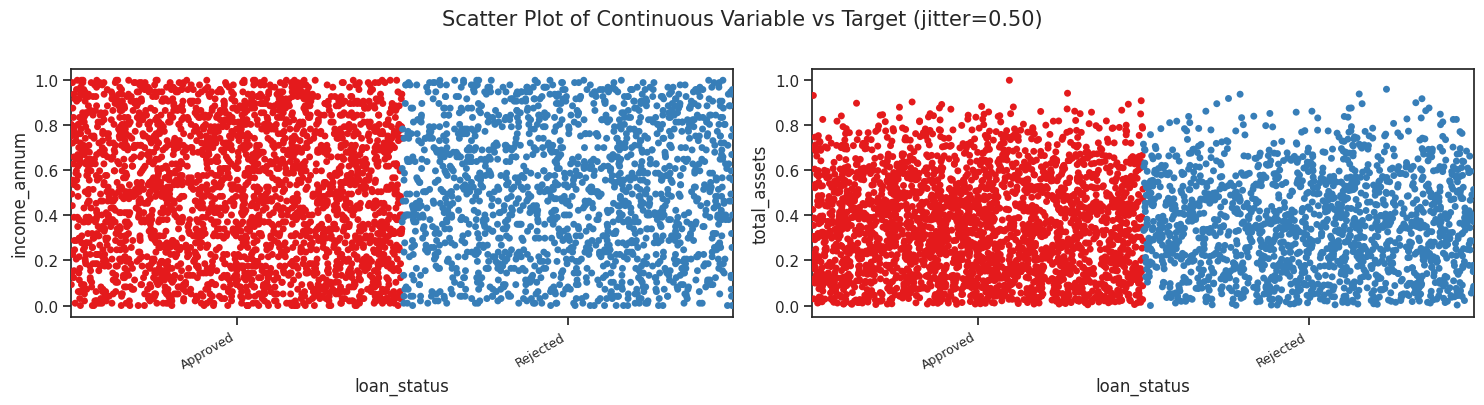

Total Number of Scatter Plots = 3


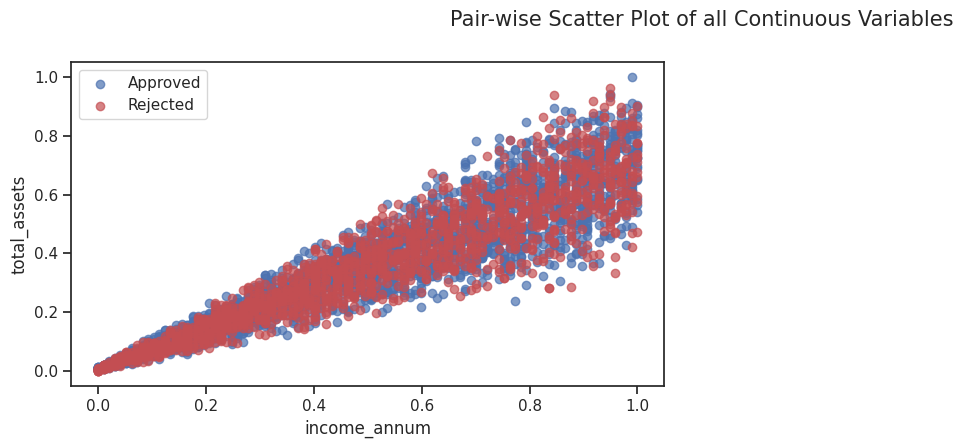

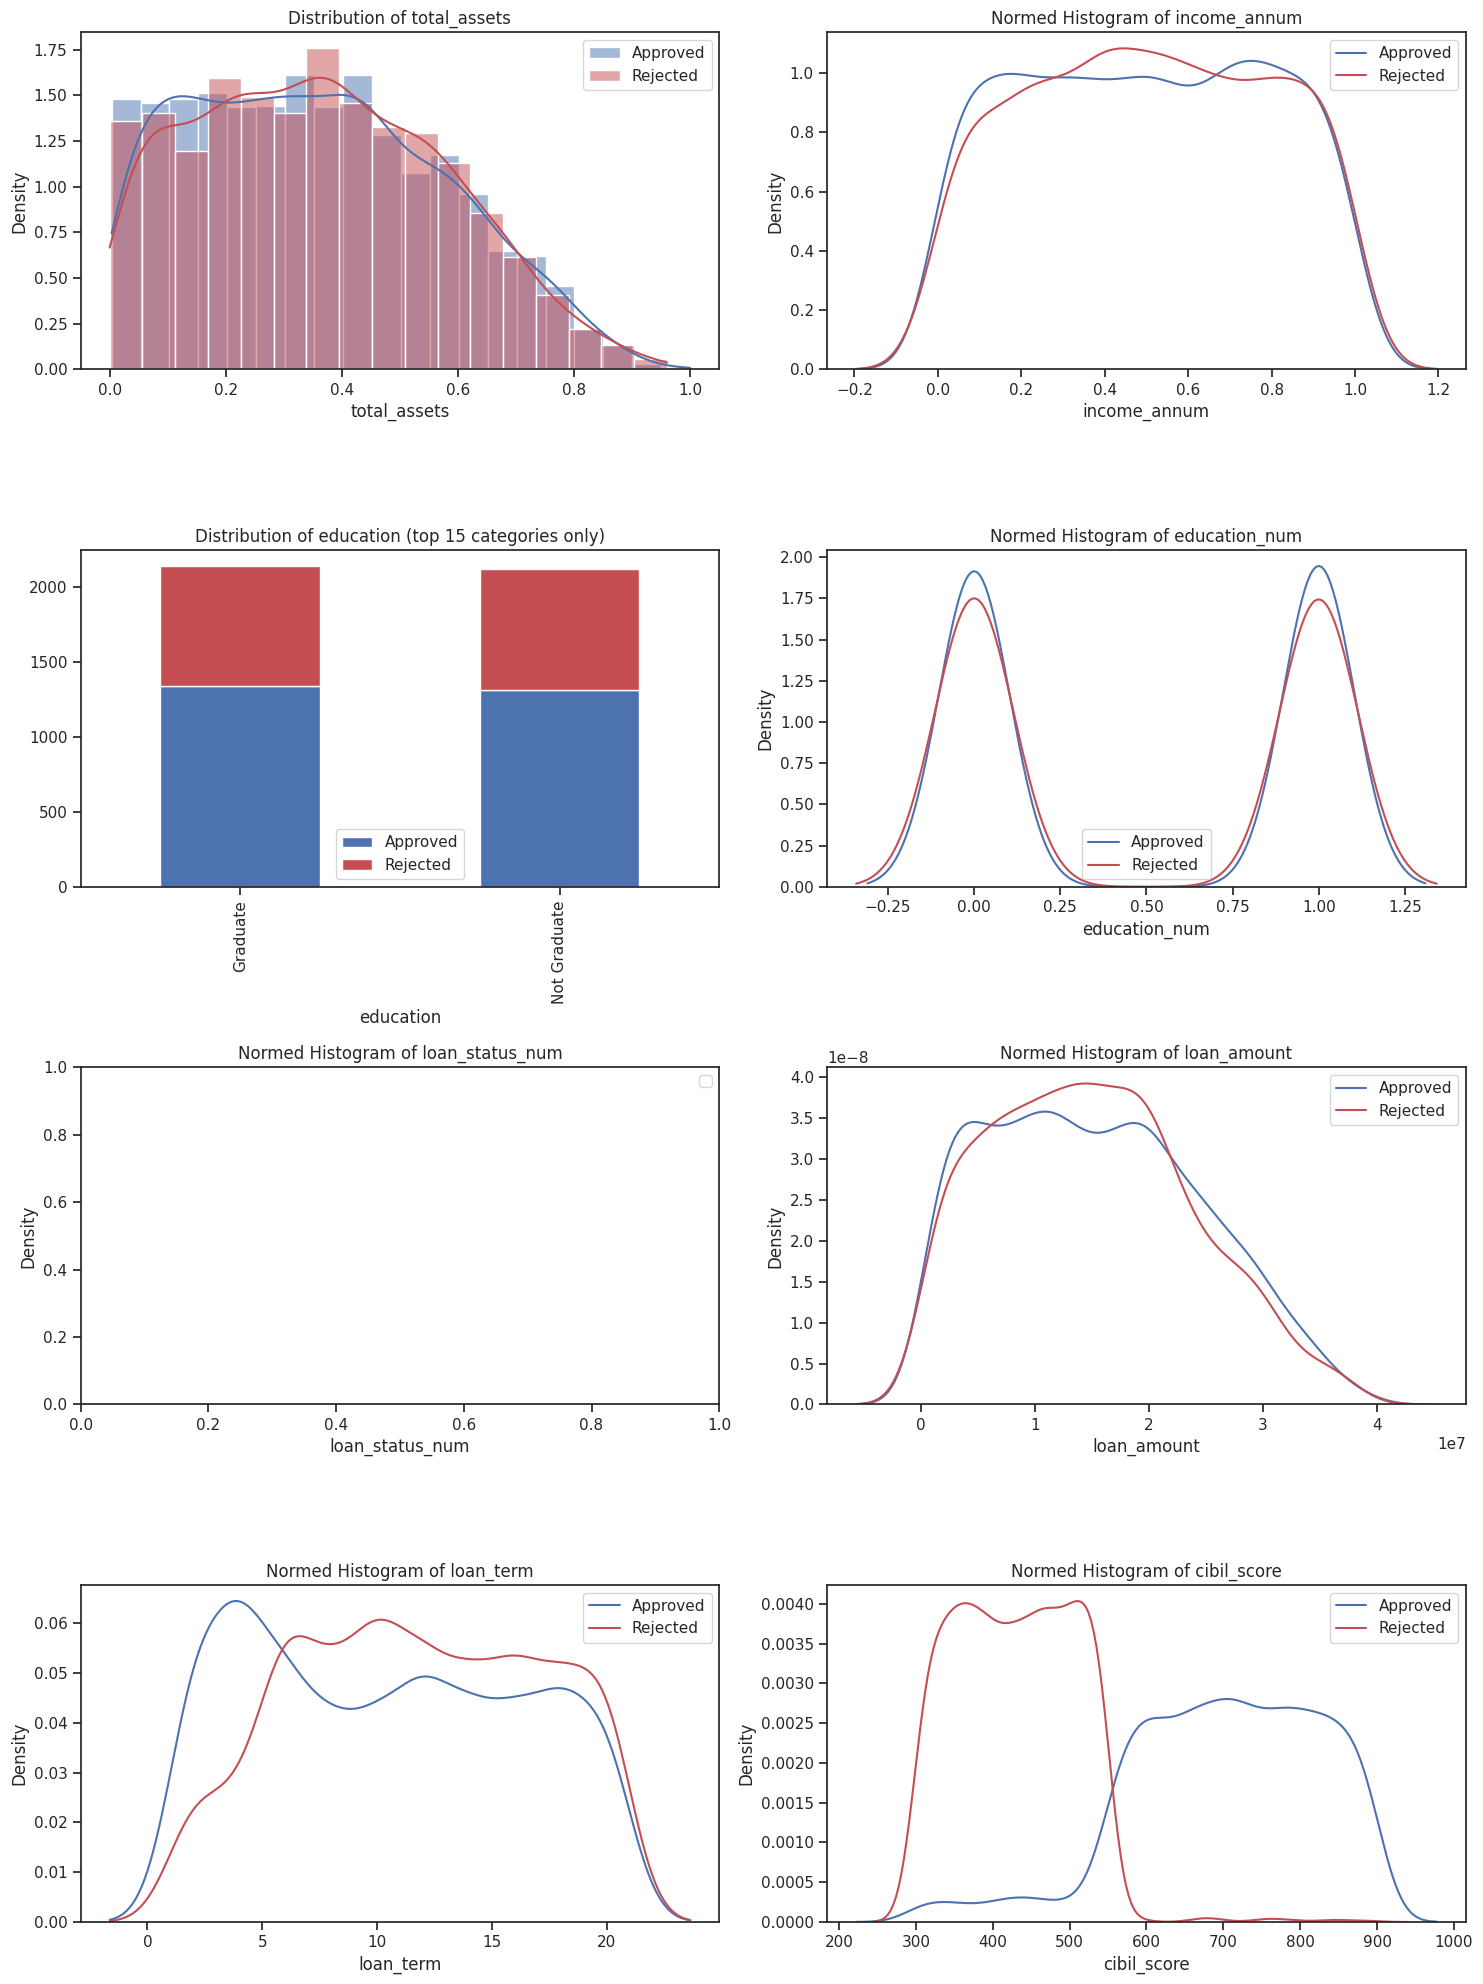

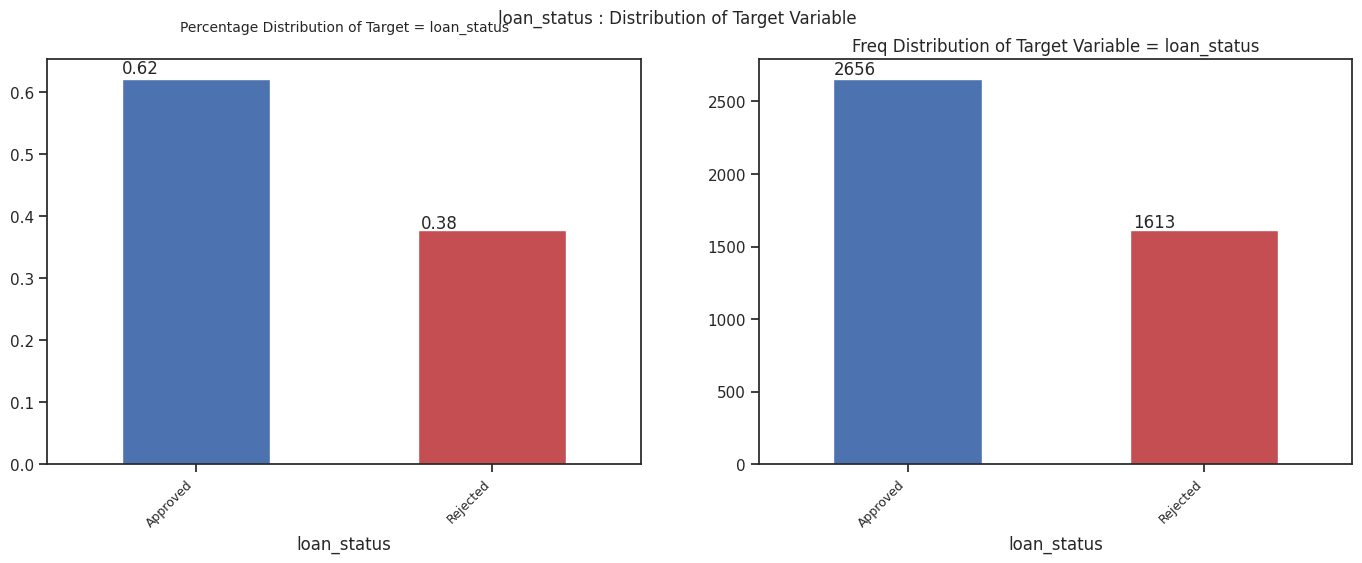

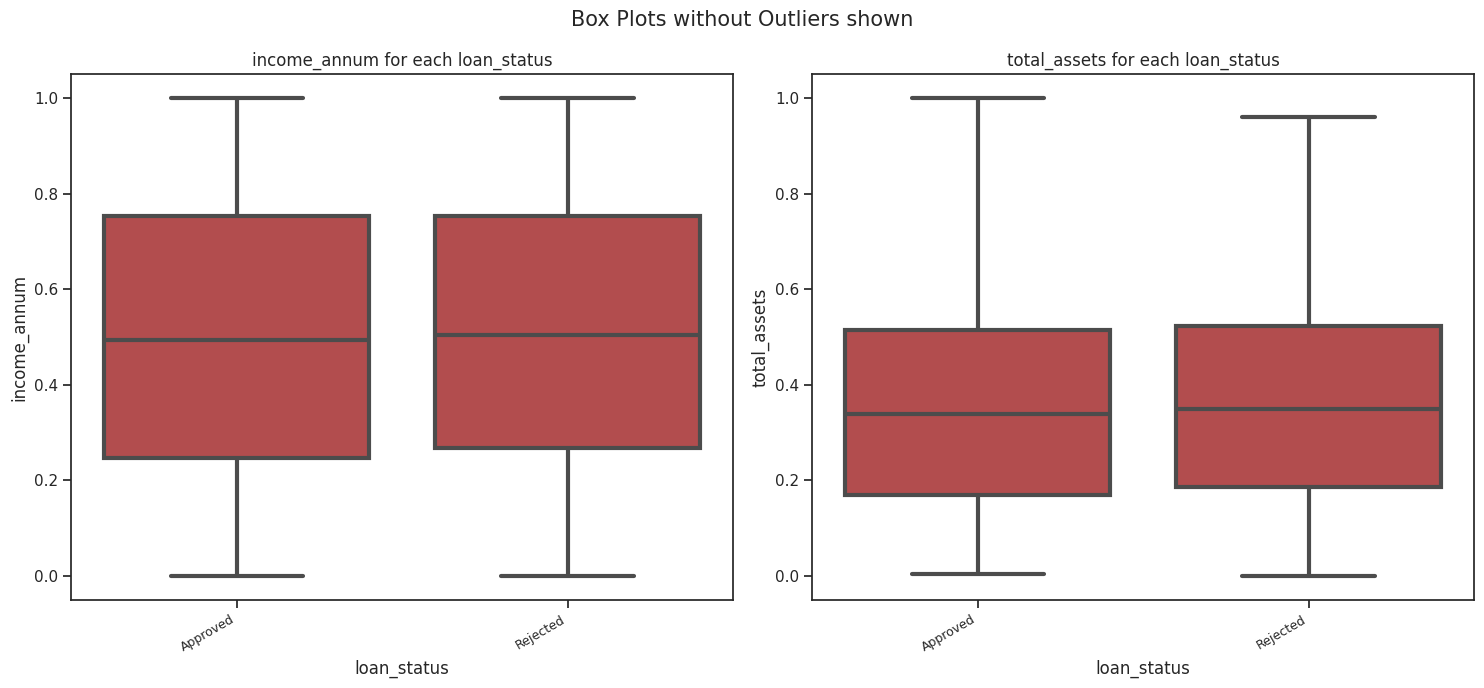

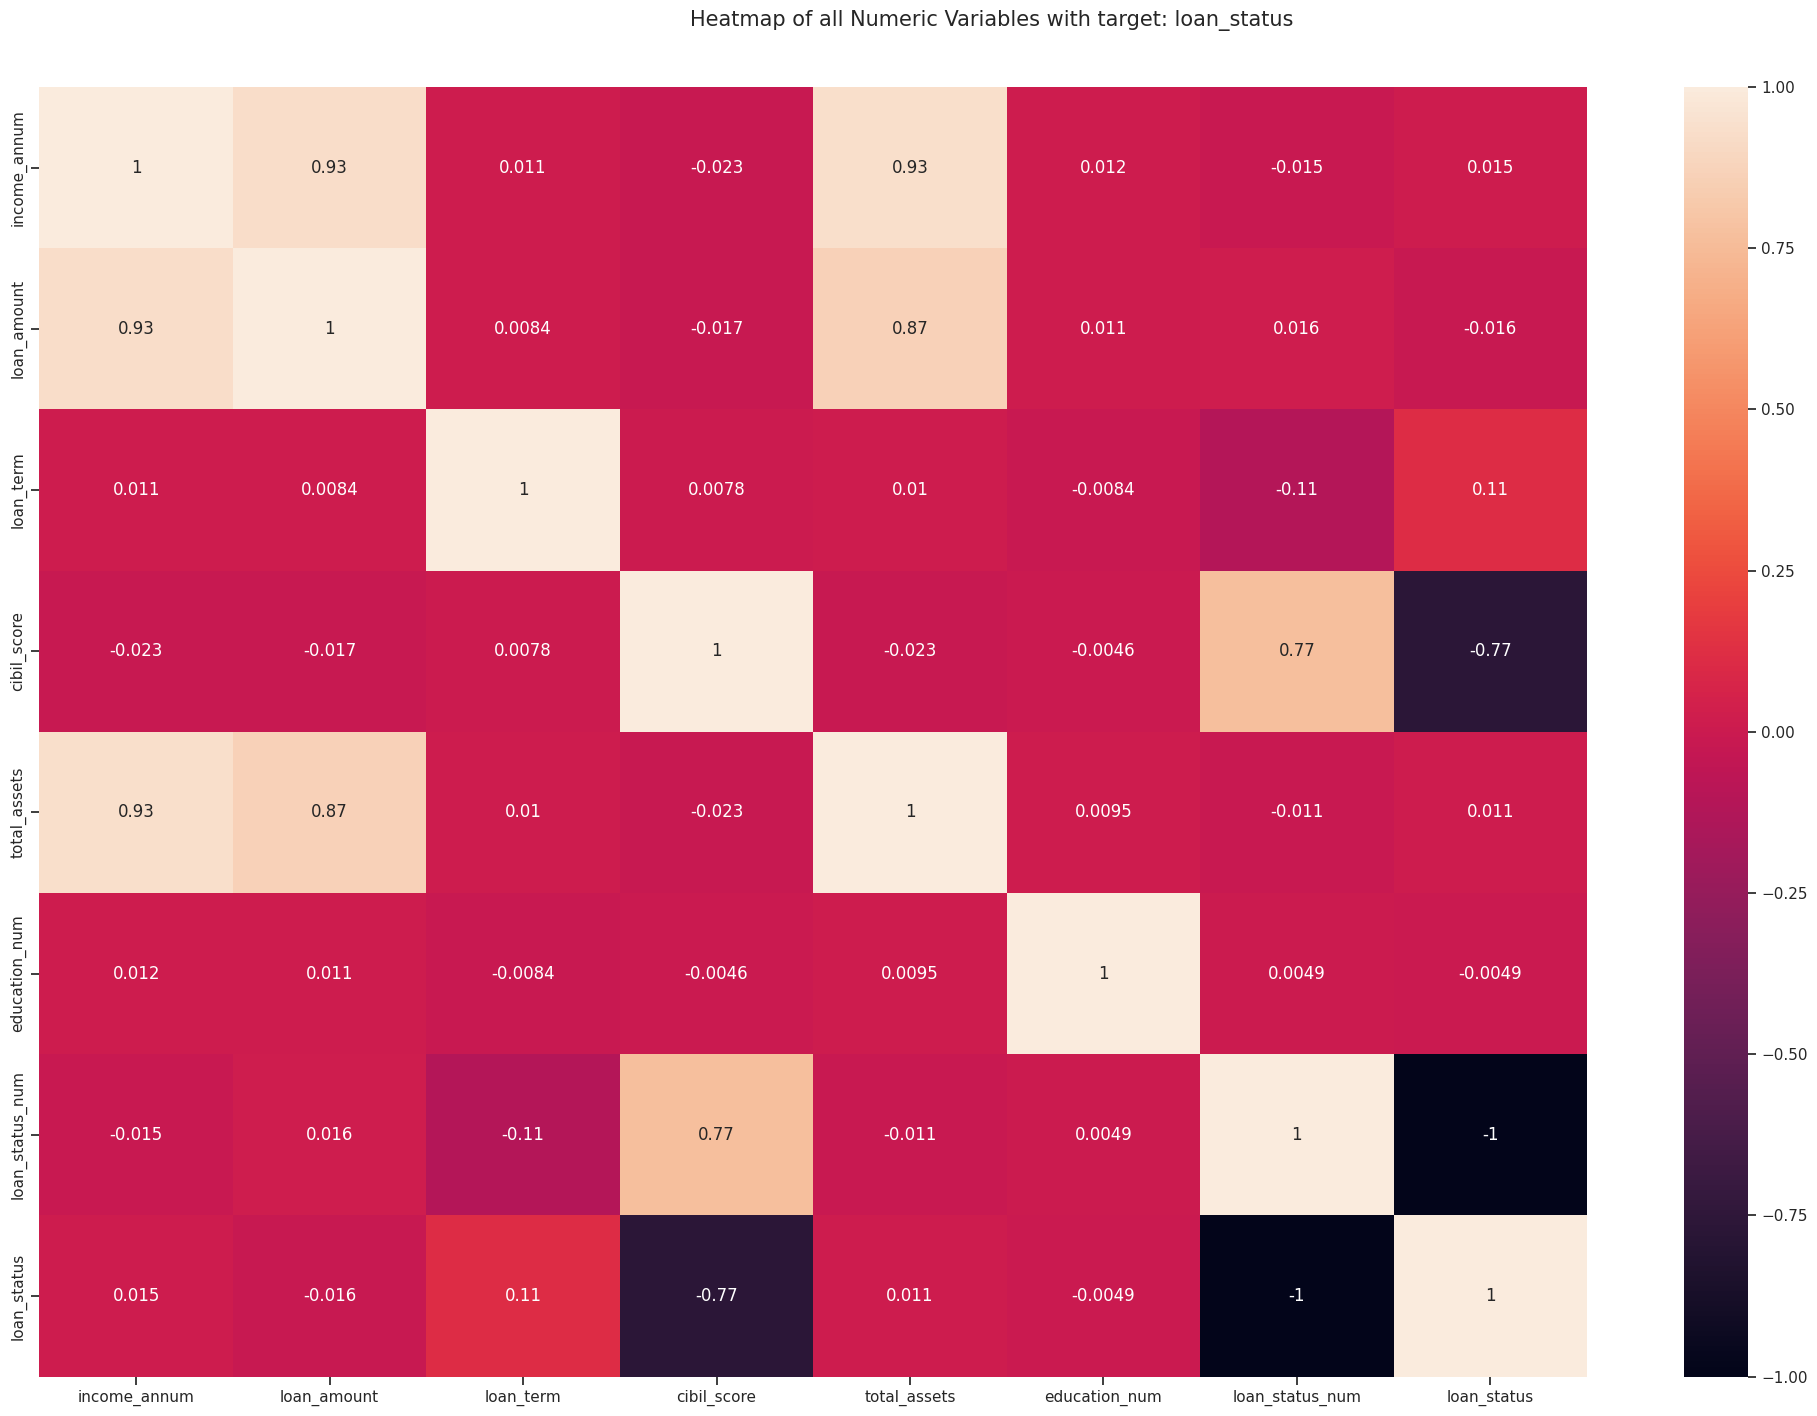

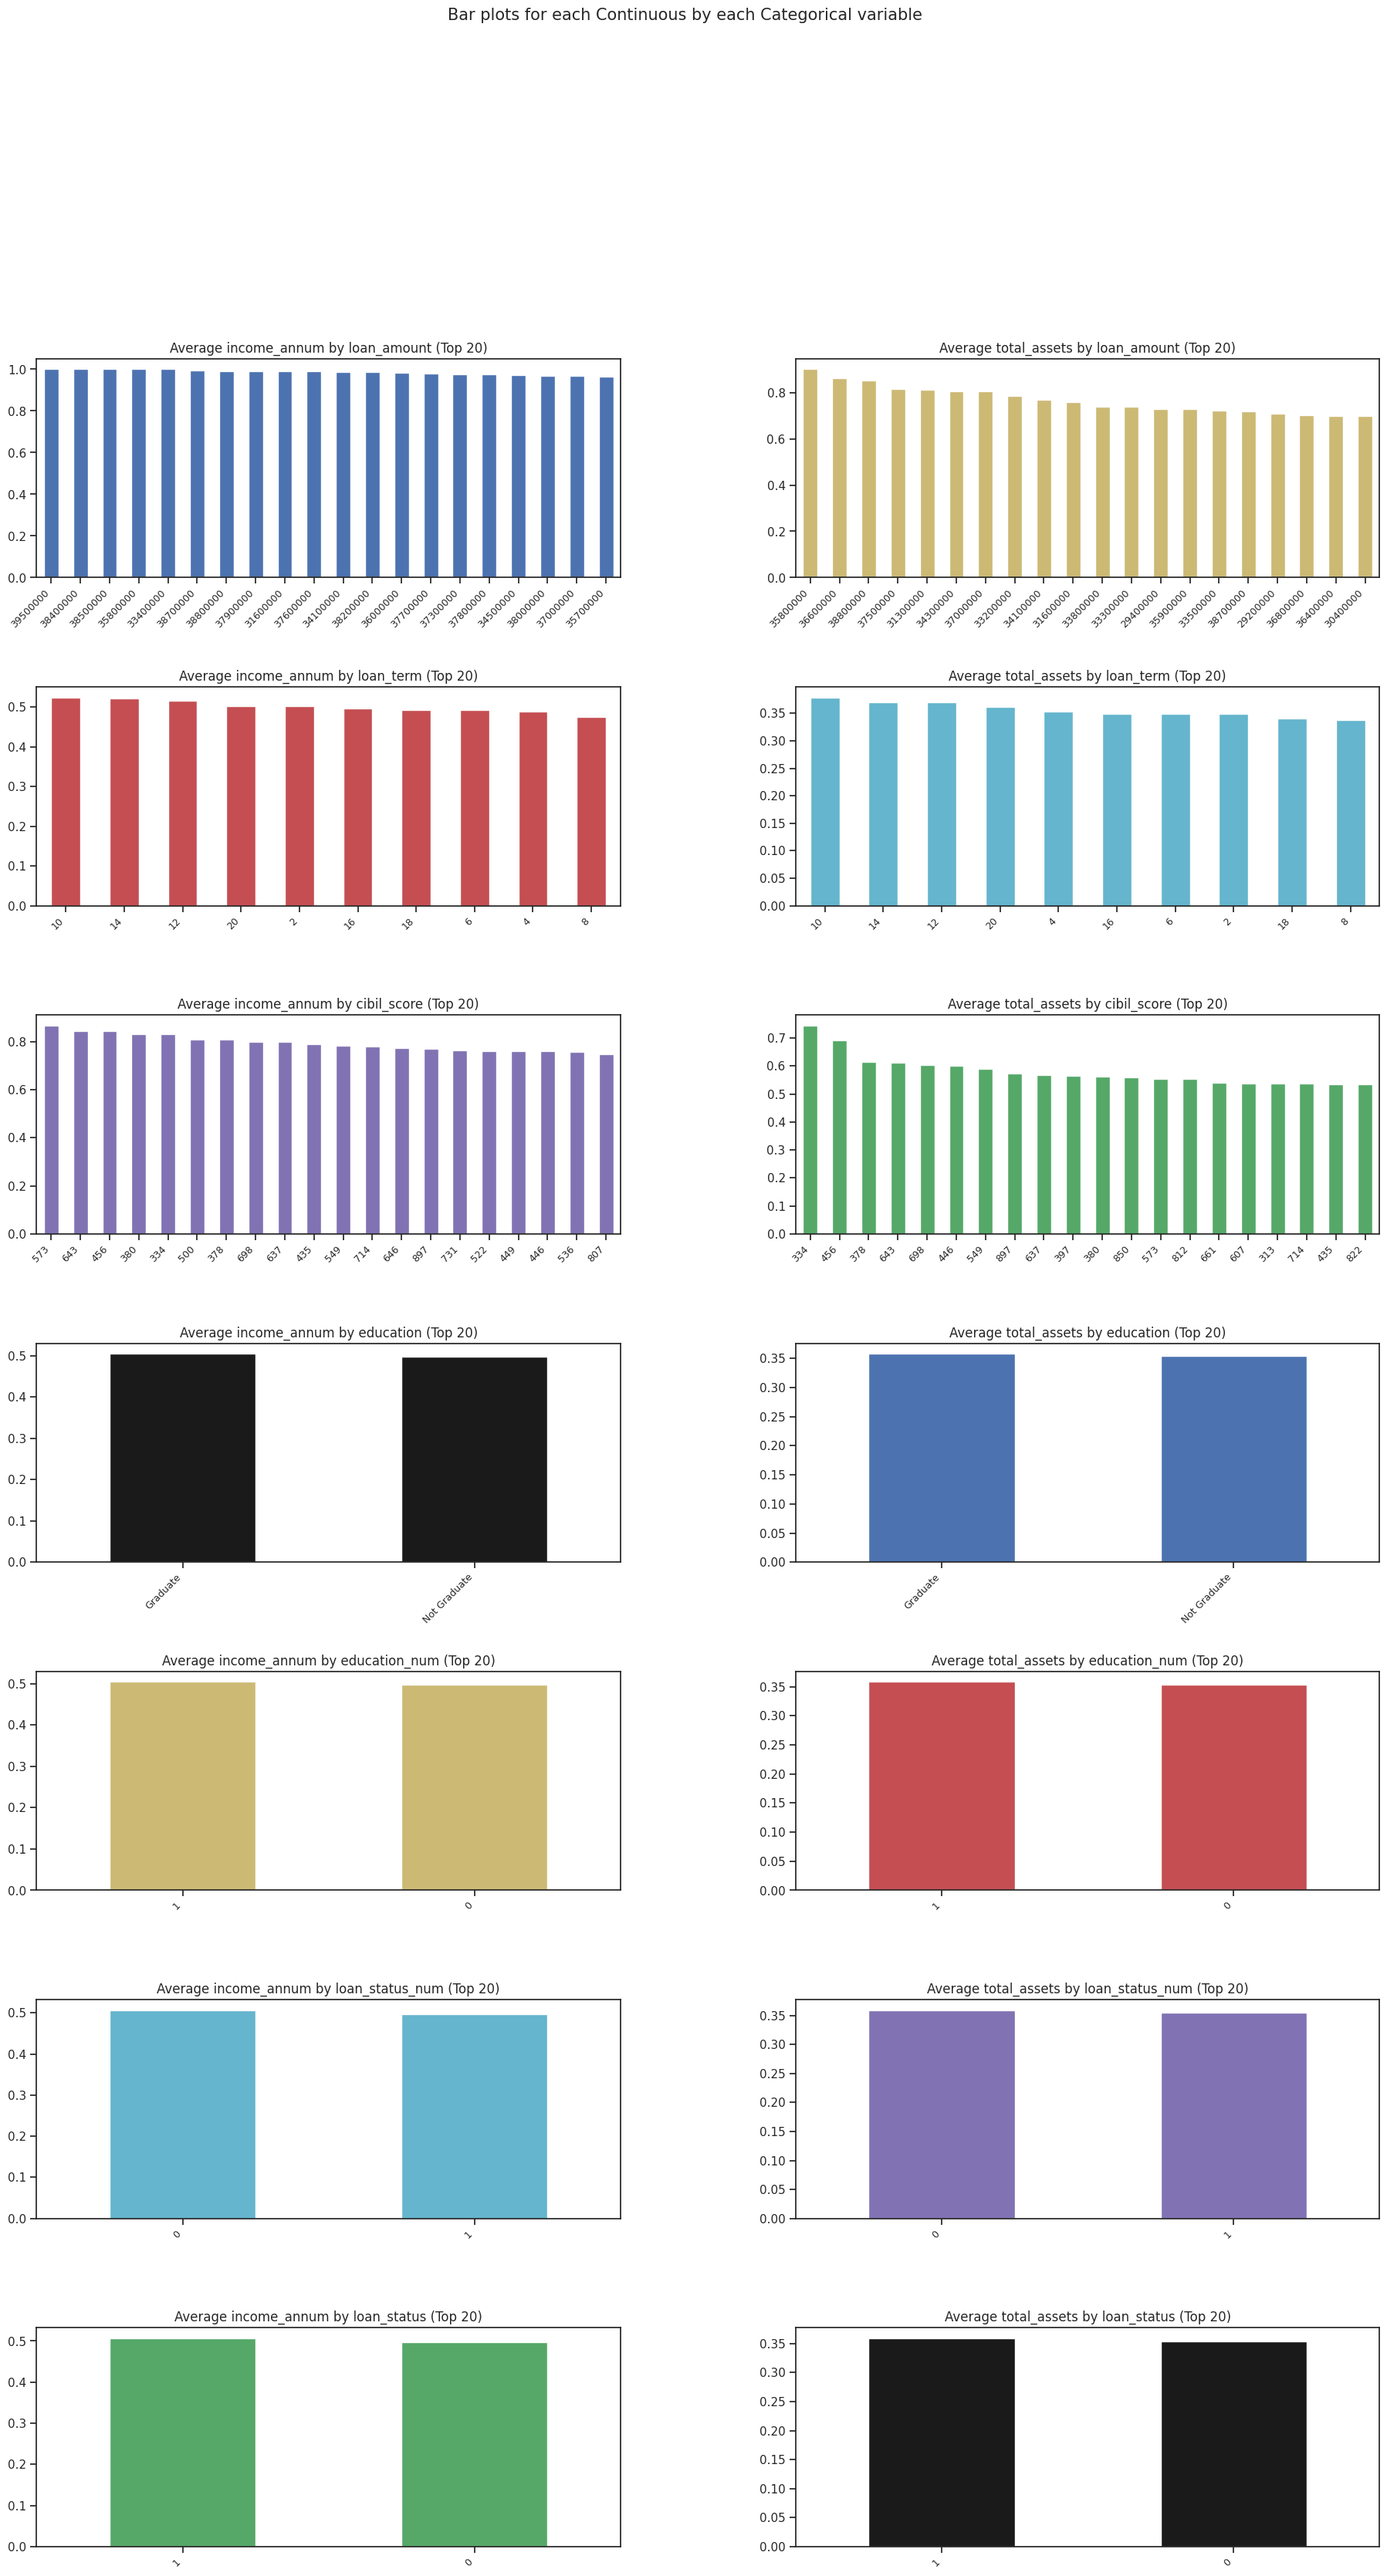

All Plots done
Time to run AutoViz = 19 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [25]:
# AutoViz example
# Replace target with your real target column name before running
dfte = AV.AutoViz(
    "", sep=",", depVar= 'loan_status', dfte=df, header=0, verbose=1, lowess=False, chart_format="svg", max_rows_analyzed=150000, max_cols_analyzed=30)

# Clear any queued figures after AutoViz so later plots behave normally in Colab
import matplotlib.pyplot as plt
plt.close('all')


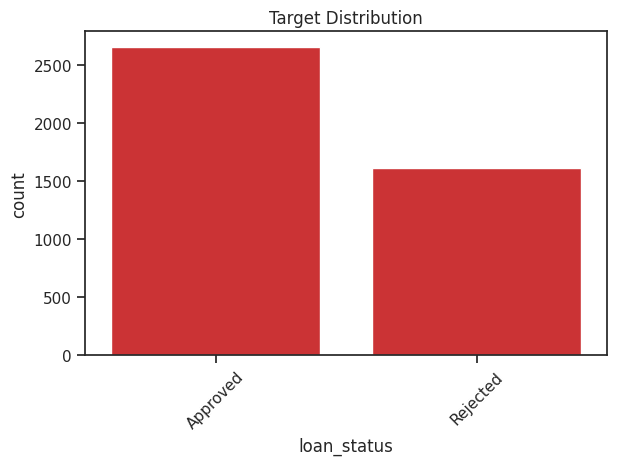

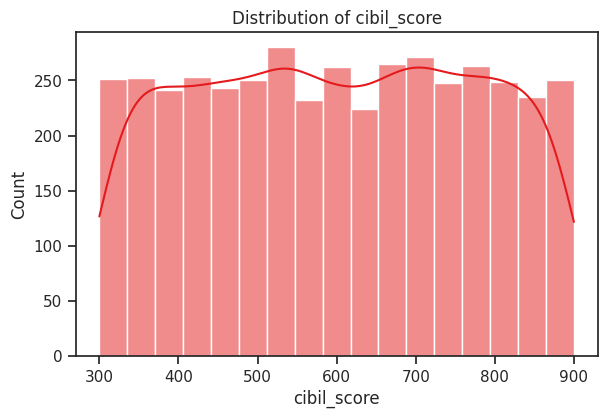

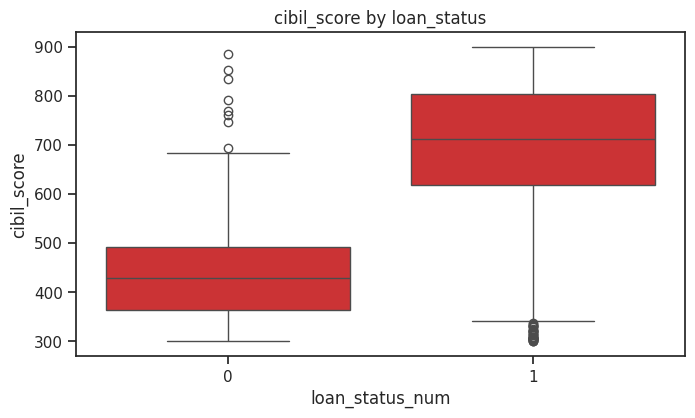

In [28]:
# Code for custom visualiations (optional)

# Example 1: target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Target Distribution")
plt.xticks(rotation=45)
plt.show()

# Example 2: numeric histogram for one variable
# Replace 'REPLACE_NUMERIC_COLUMN' with a numeric column from your dataset
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='cibil_score', kde=True)
plt.title("Distribution of cibil_score")
plt.show()

# Example 3: relationship to target
# Replace with columns from your dataset
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x= 'loan_status_num' , y='cibil_score')
plt.title("cibil_score by loan_status")
plt.show()


In [29]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y
)

### Preparation summary
To improve the models I dropped 'loan_id' due to uniqueness. After running Autoviz I noticed that 'self_employed' and 'no_of_dependents' had no correlation to 'loan_status', so both of these columns were dropped as well. I combined 'residential_asset_value', 'commercial_assets_value', 'luxury_assets_value', and 'bank_assets_value' into a single column 'total_assets', and then dropped the other assets columns. I used binary encoding to encode education and created a new column 'education_num'. Binary encoding was also used to encode the target variable 'loan_status'. I used MinMax scaling for 'total_assets' and 'income_anumm' to make the data more manageable. The data was then split using 80% to train, and 20% to test.


# Deliverable 3: Model Development, Evaluation & Interpretation

## What to include
- preprocessing pipeline
- Random Forest model
- parameter tuning
- evaluation on the test set
- confusion matrix
- kappa
- feature importance
- interpretation of what the results mean

## Reminder
You should explain results in a business-friendly way, not only with technical language.


In [ ]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [ ]:
# Identify feature columns
X = df.drop(columns=[target])
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['education', 'self_employed']
Numeric columns: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'total_assets']


In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


In [ ]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


Random Forest Classification Report:
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       531
    Rejected       0.99      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Cohen's Kappa: 0.9599


In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [ ]:
# Tune the Random Forest model
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

    Approved       0.98      1.00      0.99       531
    Rejected       0.99      0.96      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Cohen's Kappa: 0.9649


In [ ]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


In [ ]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


,feature,importance
5,num__cibil_score,0.813223
4,num__loan_term,0.064466
3,num__loan_amount,0.032588
6,num__total_assets,0.025435
2,num__income_annum,0.023691
0,num__loan_id,0.023160
1,num__no_of_dependents,0.009494
8,cat__education_ Not Graduate,0.002004
9,cat__self_employed_ No,0.002003
10,cat__self_employed_ Yes,0.001988


In [ ]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
Replace this section with your final written interpretation.


# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [ ]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)